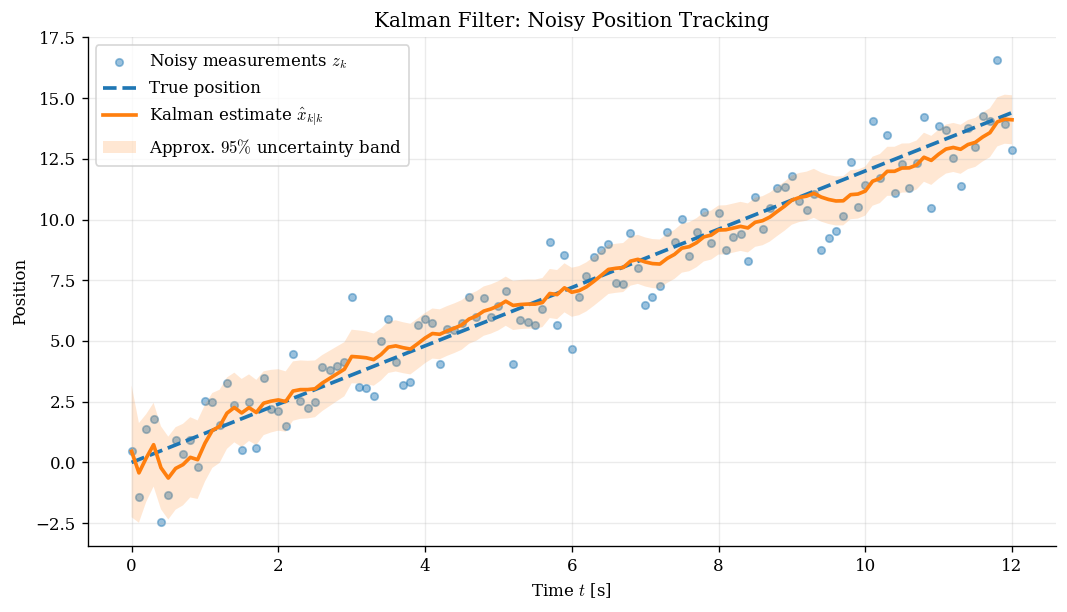

In [1]:
"""
Kalman Filter Plot Recipe: 1D Position Tracking

Author: Ziraddin Gulumjanli, 2026

This script visualizes a simple Kalman filter for a constant-velocity model.

State:
    x_k = [position_k, velocity_k]^T

Prediction:
    x_hat_k|k-1 = F x_hat_k-1|k-1
    P_k|k-1     = F P_k-1|k-1 F^T + Q

Update:
    K_k         = P_k|k-1 H^T (H P_k|k-1 H^T + R)^-1
    x_hat_k|k  = x_hat_k|k-1 + K_k (z_k - H x_hat_k|k-1)
    P_k|k      = (I - K_k H) P_k|k-1
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


@dataclass(frozen=True)
class KalmanFilterConfig:
    """Configuration for the 1D Kalman filter example."""

    random_seed: int = 42
    duration: float = 12.0
    dt: float = 0.1
    true_initial_position: float = 0.0
    true_velocity: float = 1.2
    measurement_std: float = 1.5
    process_position_std: float = 0.05
    process_velocity_std: float = 0.10
    output_dir: Path = Path("figures")


def configure_matplotlib() -> None:
    """Apply publication-style Matplotlib settings."""

    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.family": "serif",
            "mathtext.fontset": "cm",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "lines.linewidth": 2.2,
        }
    )


def generate_tracking_data(config: KalmanFilterConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate true position and noisy position measurements."""

    rng = np.random.default_rng(config.random_seed)
    time = np.arange(0.0, config.duration + config.dt, config.dt)

    true_position = config.true_initial_position + config.true_velocity * time
    measurements = true_position + rng.normal(0.0, config.measurement_std, size=time.size)

    return time, true_position, measurements


def run_kalman_filter(
    measurements: np.ndarray,
    config: KalmanFilterConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate position and velocity from noisy position measurements."""

    dt = config.dt

    transition_matrix = np.array([[1.0, dt], [0.0, 1.0]])
    observation_matrix = np.array([[1.0, 0.0]])

    process_noise = np.diag(
        [
            config.process_position_std**2,
            config.process_velocity_std**2,
        ]
    )
    measurement_noise = np.array([[config.measurement_std**2]])

    state_estimate = np.array([measurements[0], 0.0])
    covariance = np.eye(2) * 10.0

    estimates = np.zeros((measurements.size, 2), dtype=float)
    uncertainty = np.zeros(measurements.size, dtype=float)

    identity = np.eye(2)

    for step_idx, measurement in enumerate(measurements):
        # Prediction
        state_prediction = transition_matrix @ state_estimate
        covariance_prediction = transition_matrix @ covariance @ transition_matrix.T + process_noise

        # Correction
        innovation = measurement - observation_matrix @ state_prediction
        innovation_covariance = observation_matrix @ covariance_prediction @ observation_matrix.T + measurement_noise
        kalman_gain = covariance_prediction @ observation_matrix.T @ np.linalg.inv(innovation_covariance)

        state_estimate = state_prediction + (kalman_gain @ innovation).ravel()
        covariance = (identity - kalman_gain @ observation_matrix) @ covariance_prediction

        estimates[step_idx] = state_estimate
        uncertainty[step_idx] = np.sqrt(covariance[0, 0])

    return estimates, uncertainty


def plot_kalman_filter_result(
    time: np.ndarray,
    true_position: np.ndarray,
    measurements: np.ndarray,
    estimates: np.ndarray,
    uncertainty: np.ndarray,
) -> plt.Figure:
    """Plot true state, noisy measurements, Kalman estimate, and uncertainty band."""

    estimated_position = estimates[:, 0]
    lower_bound = estimated_position - 2.0 * uncertainty
    upper_bound = estimated_position + 2.0 * uncertainty

    fig, ax = plt.subplots(figsize=(9.0, 5.2))

    ax.scatter(time, measurements, s=20, alpha=0.45, label=r"Noisy measurements $z_k$")
    ax.plot(time, true_position, linestyle="--", label="True position")
    ax.plot(time, estimated_position, label=r"Kalman estimate $\hat{x}_{k|k}$")
    ax.fill_between(
        time,
        lower_bound,
        upper_bound,
        alpha=0.18,
        label=r"Approx. $95\%$ uncertainty band",
    )

    ax.set_title("Kalman Filter: Noisy Position Tracking")
    ax.set_xlabel(r"Time $t$ [s]")
    ax.set_ylabel("Position")
    ax.legend(frameon=True)
    fig.tight_layout()

    return fig


def main() -> None:
    """Run the recipe and save the figure."""

    configure_matplotlib()

    config = KalmanFilterConfig()
    config.output_dir.mkdir(parents=True, exist_ok=True)

    time, true_position, measurements = generate_tracking_data(config)
    estimates, uncertainty = run_kalman_filter(measurements=measurements, config=config)

    fig = plot_kalman_filter_result(
        time=time,
        true_position=true_position,
        measurements=measurements,
        estimates=estimates,
        uncertainty=uncertainty,
    )

    fig.savefig(config.output_dir / "control_kalman_filter_1d.png", bbox_inches="tight")
    fig.savefig(config.output_dir / "control_kalman_filter_1d.pdf", bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()
